In [ ]:
#importing libraries
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_csv("/content/sample_data/Mall_Customers.csv")
df

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [ ]:
X = df[['Annual Income (k$)','Spending Score (1-100)']]
X

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40
...,...,...
195,120,79
196,126,28
197,126,74
198,137,18


In [ ]:
#X = df[['Gender', 'Age', 'Spending Score (1-100)']]
#Encode Gender
#le = LabelEncoder()
#X['Gender'] = le.fit_transform(X['Gender'])

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled=scaler.fit_transform(X)

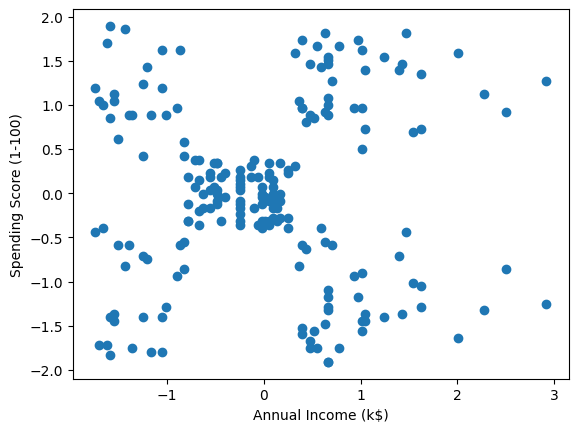

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(X_scaled[:,0],X_scaled[:,1])
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.show()

**WCSS** (Within-Cluster Sum of Squares)

Measures how close data points are to their cluster centroids.

Lower WCSS is tighter clusters.

Loop over k = 1 to 10

  Trains K-Means with different numbers of clusters.

  Stores inertia_ (WCSS) for each k.

  Plot WCSS vs k

The “elbow point” (sharp bend) indicates the optimal number of clusters.

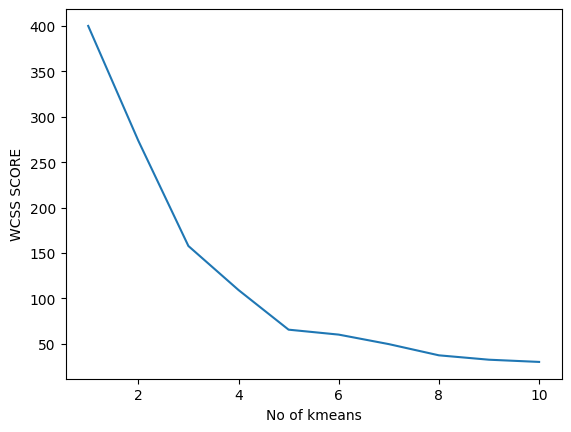

In [ ]:
#Elbow Method to find the optimal number of clusters for K-Means
from sklearn.cluster import KMeans
wcss=[]
for k in range(1,11):
    Kmeans = KMeans(n_clusters=k,random_state=42)
    Kmeans.fit(X_scaled)
    wcss.append(Kmeans.inertia_)
plt.plot(range(1,11), wcss)
plt.xlabel("No of kmeans")
plt.ylabel("WCSS SCORE")
plt.show()

Interpretation of the graph

WCSS always decreases as k increases.

Choose the value of k where the decrease slows down sharply (elbow).

That k balances:

  Good clustering

  Not too many clusters

In [ ]:
Kmeans =KMeans(n_clusters=6, random_state=42)
cluster = Kmeans.fit_predict(X_scaled)
df['cluster']=cluster

In [8]:
df

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),cluster
0,1,Male,19,15,39,5
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,5
...,...,...,...,...,...,...
195,196,Female,35,120,79,1
196,197,Female,45,126,28,3
197,198,Male,32,126,74,1
198,199,Male,32,137,18,3


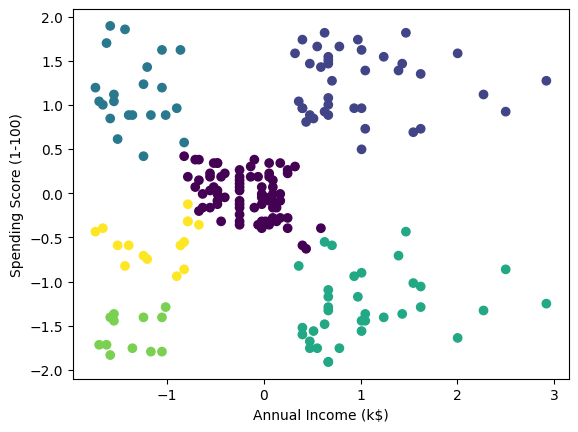

In [9]:
plt.scatter(X_scaled[:,0],X_scaled[:,1], c=cluster)
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.show()